# 03 - 08 Baseline & Architecture Experiments

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base
    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child
    raise RuntimeError(f"Could not find the project root from {start}.")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

from src.config import IMG_SHAPE, NUM_CLASSES, SEED
from src.data import load_splits
from src.models import validate_model
from src.utils import set_seed

data = load_splits()
print(data.summary())

X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


## Part 3 - Baseline Neural Network

In [2]:
# These hyperparameters are unchanged across every architecture comparison.
HIDDEN_UNITS = 128
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 50

### Hyperparameter choices

**128 neurons.** Chosen by testing. At 32 units the model stalled at 19%
accuracy with 31 of 32 hidden units dead, so ReLU had collapsed the layer to a
single effective neuron. Widths of 64 and above trained normally, and 128 was
the smallest that did so reliably while keeping the baseline simple.

**Learning rate 0.001.** Adam's default, and the midpoint of the range tested in
Part 9 (0.01 / 0.001 / 0.0001), so that sweep can show degradation in both
directions rather than hitting an edge.

**Batch size 32.** The midpoint of Part 10's range (16 / 32 / 64), and cheap at
roughly 1.9 seconds per epoch on CPU.

**50 epochs.** Validation loss reaches its minimum near epoch 45. Extending to
100 epochs gained only 0.4 points of validation accuracy while training accuracy
gained 1.1, which is memorisation rather than learning.

In [3]:
set_seed(SEED)

baseline_model = keras.Sequential(
    [
        keras.Input(shape=IMG_SHAPE),
        layers.Flatten(name="flatten"),
        layers.Dense(HIDDEN_UNITS, activation="relu", name="hidden"),
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="baseline_model",
)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

validate_model(baseline_model)   # ensures: no Conv2D, 10 outputs, BatchNorm placement
baseline_model.summary()


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
trainable = int(sum(np.prod(w.shape) for w in baseline_model.trainable_weights))

print(f"Layers (excluding Input) : {len(baseline_model.layers)}")
print(f"Trainable parameters     : {trainable:,}")
print(f"Hidden activation        : {baseline_model.get_layer('hidden').activation.__name__}")
print(f"Output activation        : {baseline_model.get_layer('output').activation.__name__}")
print(f"Loss function            : {baseline_model.loss}")
print(f"Optimizer                : {type(baseline_model.optimizer).__name__}")
print(f"Learning rate            : {float(baseline_model.optimizer.learning_rate):.3f}")

Layers (excluding Input) : 3
Trainable parameters     : 394,634
Hidden activation        : relu
Output activation        : softmax
Loss function            : sparse_categorical_crossentropy
Optimizer                : Adam
Learning rate            : 0.001


In [5]:
history = baseline_model.fit(
    data.X_train,
    data.y_train,
    validation_data=(data.X_val, data.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

Epoch 1/50
1407/1407 - 5s - 4ms/step - accuracy: 0.2929 - loss: 1.9482 - val_accuracy: 0.3358 - val_loss: 1.8314
Epoch 2/50
1407/1407 - 4s - 3ms/step - accuracy: 0.3518 - loss: 1.8146 - val_accuracy: 0.3592 - val_loss: 1.7847
Epoch 3/50
1407/1407 - 4s - 3ms/step - accuracy: 0.3658 - loss: 1.7754 - val_accuracy: 0.3642 - val_loss: 1.7655
Epoch 4/50
1407/1407 - 4s - 3ms/step - accuracy: 0.3745 - loss: 1.7543 - val_accuracy: 0.3716 - val_loss: 1.7489
Epoch 5/50
1407/1407 - 4s - 3ms/step - accuracy: 0.3794 - loss: 1.7408 - val_accuracy: 0.3754 - val_loss: 1.7352
Epoch 6/50
1407/1407 - 3s - 2ms/step - accuracy: 0.3840 - loss: 1.7271 - val_accuracy: 0.3830 - val_loss: 1.7232
Epoch 7/50
1407/1407 - 3s - 2ms/step - accuracy: 0.3902 - loss: 1.7112 - val_accuracy: 0.3804 - val_loss: 1.7156
Epoch 8/50
1407/1407 - 3s - 2ms/step - accuracy: 0.3934 - loss: 1.7012 - val_accuracy: 0.3836 - val_loss: 1.7081
Epoch 9/50
1407/1407 - 3s - 2ms/step - accuracy: 0.3965 - loss: 1.6933 - val_accuracy: 0.3814 - 

In [6]:
H = history.history

print(f"Final training accuracy   : {H['accuracy'][-1]:.4f}")
print(f"Final validation accuracy : {H['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy  : {max(H['val_accuracy']):.4f} (epoch {int(np.argmax(H['val_accuracy']))+1})")
print(f"Lowest validation loss    : {min(H['val_loss']):.4f} (epoch {int(np.argmin(H['val_loss']))+1})")
print(f"Generalization gap        : {H['accuracy'][-1] - H['val_accuracy'][-1]:+.4f}")
print(f"Random-guess baseline     : {1/NUM_CLASSES:.4f}")

Final training accuracy   : 0.4249
Final validation accuracy : 0.4026
Best validation accuracy  : 0.4074 (epoch 43)
Lowest validation loss    : 1.6608 (epoch 45)
Generalization gap        : +0.0223
Random-guess baseline     : 0.1000


In [7]:
RESULTS = ROOT / "Results"
RESULTS.mkdir(exist_ok=True)

record = {
    "name": "baseline",
    "architecture": [HIDDEN_UNITS],
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "adam",
    "dropout": None,
    "batchnorm": False,
    "early_stopping": False,
    "trainable_params": trainable,
    "best_val_accuracy": float(max(H["val_accuracy"])),
    "min_val_loss": float(min(H["val_loss"])),
    "final_train_accuracy": float(H["accuracy"][-1]),
    "history": {k: [float(x) for x in v] for k, v in H.items()},
}
(RESULTS / "baseline.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
print("saved -> Results/baseline.json")

saved -> Results/baseline.json


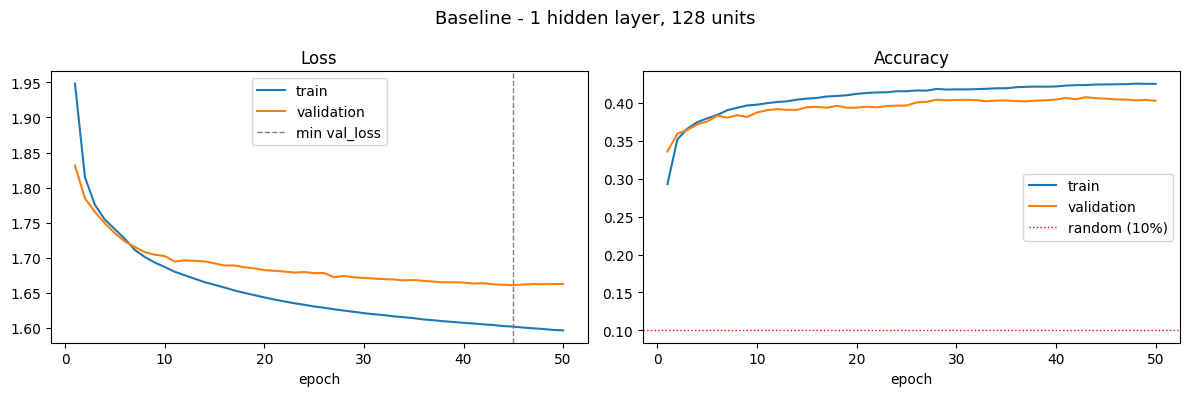

In [8]:
# Read from disk, not from H: the Part 4 save loop rebinds H to the last
# model, so re-running cells out of order would silently plot the wrong run.
Hb = json.loads((RESULTS / "baseline.json").read_text())["history"]
epochs = range(1, len(Hb["loss"]) + 1)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline - 1 hidden layer, 128 units", fontsize=13)

ax_loss.plot(epochs, Hb["loss"], label="train")
ax_loss.plot(epochs, Hb["val_loss"], label="validation")
ax_loss.axvline(int(np.argmin(Hb["val_loss"])) + 1, ls="--", c="gray", lw=1, label="min val_loss")
ax_loss.set_title("Loss"); ax_loss.set_xlabel("epoch"); ax_loss.legend()

ax_acc.plot(epochs, Hb["accuracy"], label="train")
ax_acc.plot(epochs, Hb["val_accuracy"], label="validation")
ax_acc.axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
ax_acc.set_title("Accuracy"); ax_acc.set_xlabel("epoch"); ax_acc.legend()

plt.tight_layout(); plt.show()

### Baseline results

0.4026 validation accuracy and a 10% random-guess floor is about 4x the chance.

The generalization gap is only +0.022, so the model
is underfitting, not overfitting. The next step is more capacity, not
regularization: Dropout cannot fix a model that has not yet fitted its
training data.

### Part 3 answers

> **Why ReLU for the hidden layer?**
>
> It avoids the vanishing gradients that sigmoid and tanh suffer when they saturate. It is also just max(0, z).
> 
> 
>
> The problem that faced us in this project: ReLU outputs zero for negative
> inputs, so a unit pushed there gets zero gradient and never recovers. At 32
> units, 31 were dead and the model maxed at 19%. Increasing neurons to 128 leaves
> enough surviving units.

> **Why Softmax for the output layer?**
>
> The ten classes are mutually exclusive, so the outputs should form one
> probability distribution summing to 1, so raising one class lowers the others.
> Sigmoid would score each class independently, it also would not sum to 1.

> **Why this loss function?**
>
> Cross-entropy is -log(p) for the true class, so a confident wrong prediction
> is punished hard. MSE would treat the outputs as arbitrary numbers, penalise
> errors far more gently, and give a flatter gradient through softmax.
>
> Sparse cross-entropy because our labels are integers of shape (45000,), not
> one-hot. Identical mathematically to plain cross-entropy.

## Part 4 - Architecture Experiment

In [9]:
ARCHITECTURES = {
    "shallow": [128],
    "medium":  [128, 128, 128],
    "deep":    [128, 128, 128, 128, 128],
}

In [10]:
def build_model(name, hidden_units):
    #Same seed, same optimizer, same loss, only number of hidden layers differ.
    set_seed(SEED)

    net = [keras.Input(shape=IMG_SHAPE), layers.Flatten(name="flatten")]
    for i, units in enumerate(hidden_units, start=1):
        net.append(layers.Dense(units, activation="relu", name=f"hidden_{i}"))
    net.append(layers.Dense(NUM_CLASSES, activation="softmax", name="output"))

    model = keras.Sequential(net, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    validate_model(model)
    return model

In [11]:
models = {}
for name, units in ARCHITECTURES.items():
    models[name] = build_model(name, units)
    print(f"\n{'='*70}\n{name.upper()}  -  {len(units)} hidden layer(s), units {units}\n{'='*70}")
    models[name].summary()

print(f"\n{'Model':<10}{'Hidden layers':>15}{'Trainable params':>20}")
for name, m in models.items():
    print(f"{name:<10}{len(ARCHITECTURES[name]):>15}{m.count_params():>20,}")


SHALLOW  -  1 hidden layer(s), units [128]


Model: "shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,682 (1.76 MB)

 Trainable params: 460,682 (1.76 MB)

 Non-trainable params: 0 (0.00 B)


Model       Hidden layers    Trainable params
shallow                 1             394,634
medium                  3             427,658
deep                    5             460,682


## Part 5 - Fair Model Comparison

In [12]:
histories = {}
for name, model in models.items():
    print(f"training {name} ...")
    histories[name] = model.fit(
        data.X_train, data.y_train,
        validation_data=(data.X_val, data.y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    ).history
    H = histories[name]
    print(f"  best val_acc {max(H['val_accuracy']):.4f} | "
          f"min val_loss {min(H['val_loss']):.4f} | "
          f"gap {H['accuracy'][-1] - H['val_accuracy'][-1]:+.4f}")

training shallow ...
  best val_acc 0.4074 | min val_loss 1.6608 | gap +0.0223
training medium ...
  best val_acc 0.4584 | min val_loss 1.5450 | gap +0.1253
training deep ...
  best val_acc 0.4600 | min val_loss 1.5719 | gap +0.1528


In [13]:
for name, H in histories.items():
    record = {
        "name": name,
        "architecture": ARCHITECTURES[name],
        "hidden_layers": len(ARCHITECTURES[name]),
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "optimizer": "adam",
        "dropout": None,
        "batchnorm": False,
        "early_stopping": False,
        "trainable_params": int(models[name].count_params()),
        "best_val_accuracy": float(max(H["val_accuracy"])),
        "min_val_loss": float(min(H["val_loss"])),
        "final_train_accuracy": float(H["accuracy"][-1]),
        "history": {k: [float(x) for x in v] for k, v in H.items()},
    }
    (RESULTS / f"{name}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
print("saved ->", ", ".join(f"Results/{n}.json" for n in histories))

saved -> Results/shallow.json, Results/medium.json, Results/deep.json


## Part 6 - Learning Curves

In [14]:
def plot_curves(name):
    hist = histories[name]
    epochs = range(1, len(hist["loss"]) + 1)
    best = int(np.argmin(hist["val_loss"])) + 1

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{name.capitalize()}: {len(ARCHITECTURES[name])} hidden layer(s), 128 units",
                 fontsize=13)

    ax_loss.plot(epochs, hist["loss"], label="train")
    ax_loss.plot(epochs, hist["val_loss"], label="validation")
    ax_loss.axvline(best, ls="--", c="gray", lw=1, label=f"min val_loss (ep {best})")
    ax_loss.set_title("Loss"); ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss"); ax_loss.legend()

    ax_acc.plot(epochs, hist["accuracy"], label="train")
    ax_acc.plot(epochs, hist["val_accuracy"], label="validation")
    ax_acc.axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
    ax_acc.set_title("Accuracy"); ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy"); ax_acc.legend()

    plt.tight_layout()
    plt.show()

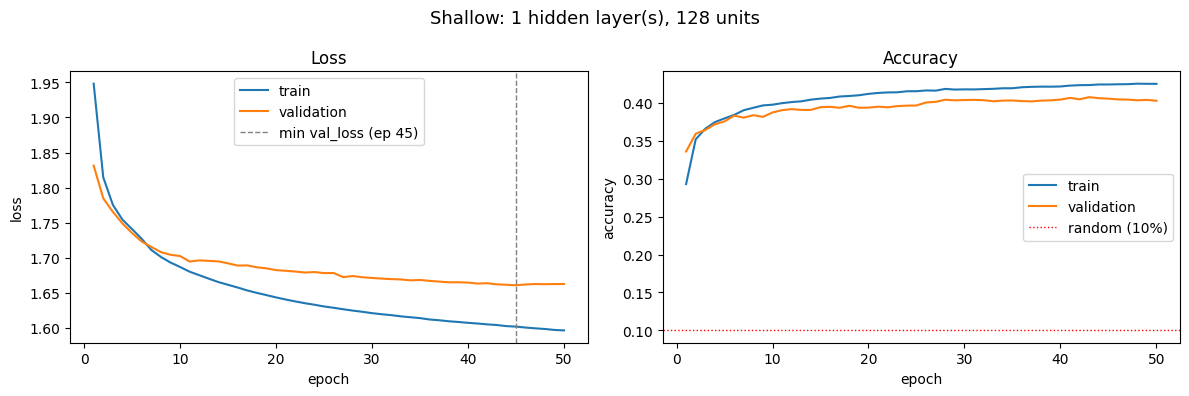

In [15]:
plot_curves("shallow")

**Shallow: underfitting.**

Curves stay close (gap 0.0178) and both plateau near 42%. Validation loss
bottoms at epoch 45 and ends at 1.6626 against a minimum of 1.6608, so it never
meaningfully rises. Not memorising, just too small to fit the data.

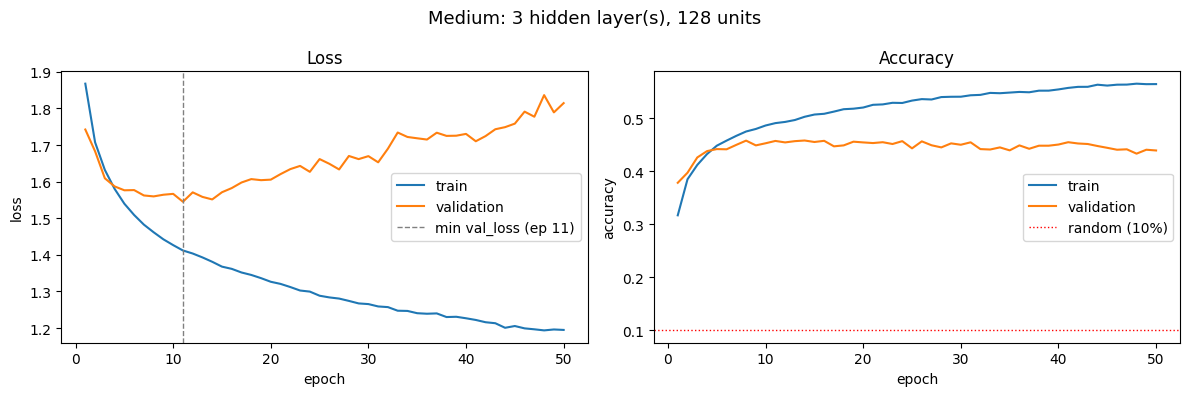

In [16]:
plot_curves("medium")

**Medium: good fit early, then overfitting.**

Validation loss bottoms at epoch 11 (1.5450) and rises 17% to 1.8144, while
training loss keeps falling. Gap 0.1073. The first 11 epochs are learning, the
rest is memorisation.

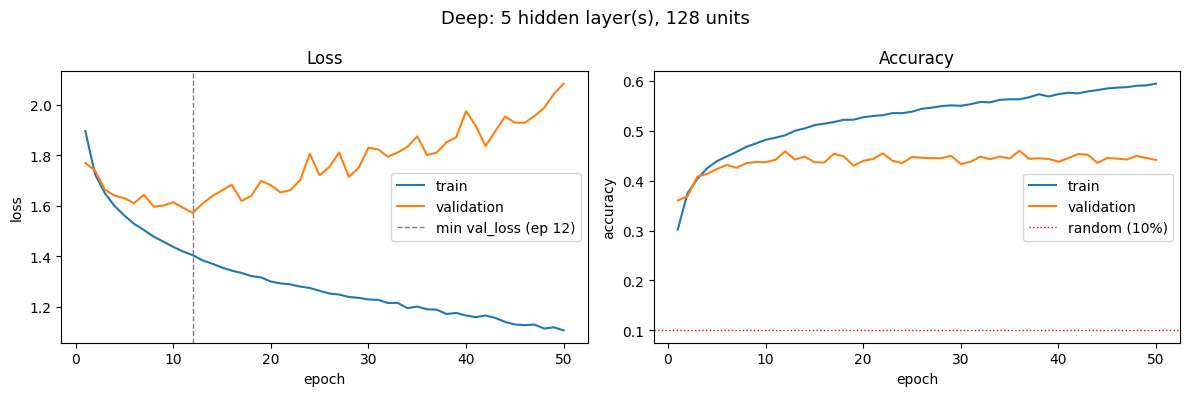

In [17]:
plot_curves("deep")

**Deep: strongest overfitting.**

Validation loss bottoms at epoch 12 (1.5719) then rises 33% to 2.0840, the
largest of the three. Highest training accuracy (0.5944), widest gap (0.1344),
yet worse validation loss than medium.

## Part 7 - Architecture Comparison

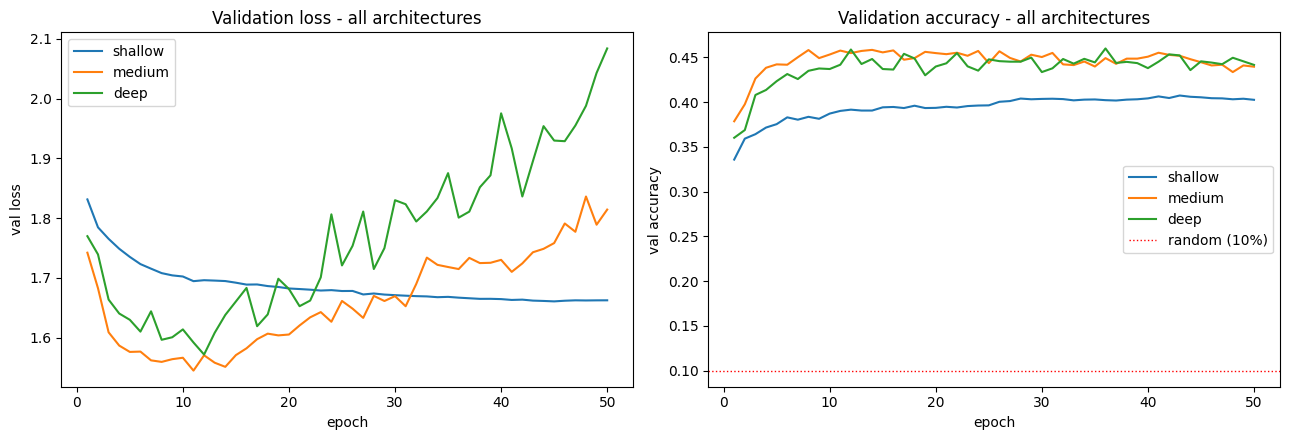

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, hist in histories.items():
    epochs = range(1, len(hist["loss"]) + 1)
    axes[0].plot(epochs, hist["val_loss"], label=name)
    axes[1].plot(epochs, hist["val_accuracy"], label=name)

axes[0].set_title("Validation loss - all architectures"); axes[0].set_ylabel("val loss")
axes[1].set_title("Validation accuracy - all architectures"); axes[1].set_ylabel("val accuracy")
axes[1].axhline(0.1, ls=":", c="red", lw=1, label="random (10%)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend()

plt.tight_layout()
plt.show()

In [19]:
table = pd.DataFrame([{
    "Model": name.capitalize(),
    "Hidden Layers": len(ARCHITECTURES[name]),
    "Parameters": f"{models[name].count_params():,}",
    "Best Train Acc.": round(max(hist["accuracy"]), 4),
    "Best Val Acc.": round(max(hist["val_accuracy"]), 4),
    "Min Val Loss": round(min(hist["val_loss"]), 4),
    "Min Val Loss Epoch": int(np.argmin(hist["val_loss"])) + 1,
    "Gap": round(max(hist["accuracy"]) - max(hist["val_accuracy"]), 4),
} for name, hist in histories.items()])

display(table)

,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Min Val Loss Epoch,Gap
0,Shallow,1,"394,634",0.4252,0.4074,1.6608,45,0.0178
1,Medium,3,"427,658",0.5657,0.4584,1.5450,11,0.1073
2,Deep,5,"460,682",0.5944,0.4600,1.5719,12,0.1344


### Part 7 answers

> **Which architecture learned the Training Data best?**
>
> Deep, at 0.5944. Training accuracy increased with depth.

> **Which architecture achieved the best Validation performance?**
>
> Deep is nominally highest at 0.4600, but medium's 0.4584 is within short noise of
> (0.0016 is 8 images out of 5,000). Medium is clearly better on validation loss,
> 1.5450 against 1.5719, so medium is the stronger performer.

> **Which model showed the largest gap between Training and Validation?**
>
> Deep at 0.1344.

> **Did increasing depth always improve performance?**
>
> No. Going from 1 to 3 layers gained 5.1 points while 3 to 5 gained 0.16 only,
> and validation loss got worse. Preliminary testing at 10 hidden layers degraded
> the model further, with training accuracy falling despite the extra
> parameters, indicating that depth eventually makes optimization harder rather
> than improving representation.


> **Which model showed the strongest evidence of overfitting?**
>
> Deep. Highest training accuracy, largest gap, and validation loss bottoming
> at epoch 12 then rising for 38 epochs while training loss kept falling.

> **Which architecture will you continue with in the next stage?**
>
> Medium, 3 hidden layers of 128 units.

> **Why did you select it?**
>
> Same validation accuracy as deep within noise, but the lowest validation loss,
> a smaller gap, and 33,024 fewer parameters. Depth beyond 3 introduced overfitting,
> not generalization.

## Part 8 - Model Diagnosis

Selected model: **Medium**, 3 hidden layers of 128 neurons, 427,658 parameters.

### Observation

Training loss decreases steadily across all 50 epochs, from 1.868 to 1.195, and
training accuracy increases from 0.317 to 0.565. Validation behaves differently: it
improves for only the first 11 epochs, reaching a minimum loss of 1.5450, then
reverses and rises to 1.8144 by epoch 50, an increase of 17.4%. Validation
accuracy maxes at 0.4584 on epoch 14 and falls down to 0.4396.

The two curves therefore move in opposite directions for most of training, and
the gap widens from 0.1073 at the best epoch to 0.1253 at the final one.

### Diagnosis

**Overfitting**, beginning around epoch 11.

Not underfitting: the model reaches 0.565 training accuracy and its training
loss is still falling at epoch 50, so it clearly has the capacity to keep
fitting the data. Not optimization instability either: the curves are smooth,
with epoch-to-epoch validation loss varying by only 0.021 and a largest single
jump of 0.059.

### Evidence

1. Validation loss reaches its minimum at epoch 11 and rises steadily
   afterwards (1.545, 1.605, 1.670, 1.730, 1.814 at epochs 11, 20, 30, 40, 50)
   while training loss continues to fall over the same span.
2. Validation accuracy peaks at epoch 14 and then declines, so the remaining 36
   epochs make the model actively worse on unseen data.
3. The generalization gap widens as training continues, from 0.1073 to 0.1253.

Together these show the model is learning patterns specific to the training set
rather than ones that generalize.

### First Proposed Improvement

**Early Stopping on validation loss, with the best weights restored.**

This responds directly to the observation: the best model already exists at
epoch 11, and every epoch after it degrades validation performance. Early
stopping recovers that model at no cost, needs no change to the architecture,
and would improve validation loss from 1.8144 to 1.5450.

It treats the symptom rather than the cause, so the natural follow-up is
Dropout, which would let the model train longer before diverging.

Learning rate is deliberately not proposed first: the curves show no
oscillation, so there is no evidence that the step size is the problem.